<a href="https://colab.research.google.com/github/Sirigalla34/deep-learning-programs/blob/main/LSTM_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 170ms/step - accuracy: 0.6750 - loss: 0.5789 - val_accuracy: 0.8612 - val_loss: 0.3397
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 168ms/step - accuracy: 0.8938 - loss: 0.2738 - val_accuracy: 0.8678 - val_loss: 0.3278
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 170ms/step - accuracy: 0.9320 - loss: 0.1905 - val_accuracy: 0.8718 - val_loss: 0.3408
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 173ms/step - accuracy: 0.9441 - loss: 0.1537 - val_accuracy: 0.8650 - val_loss: 0.3453
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.9570 - loss: 0.1242 - val_accuracy: 0.8620 - val_loss: 0.3640
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8541 - loss: 0.3776
Test Accuracy: 0.8546000123023987


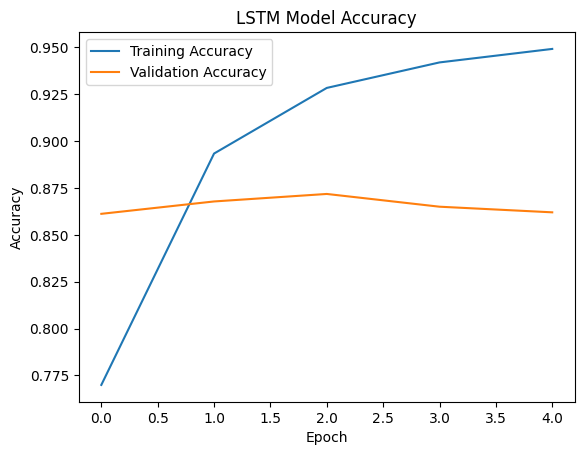

In [ ]:
# LSTM for Text classification
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset (keep top 10,000 frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Make all reviews the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)
# Build the LSTM model
model = Sequential()

# Embedding layer converts word numbers into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))

# LSTM layer for learning long-term text patterns
model.add(LSTM(64))

# Output layer for binary sentiment classification
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

# Plot training accuracy
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Accuracy")
plt.show()